
PATIENT: P01 (Ch)

===== FILE: Data_Ch_D.csv =====
K-Push:
     time  force
0  0.000    0.0
1  0.001    0.0
2  0.002    0.0
3  0.003    0.0
4  0.004    0.0

Wrist:
     time        qx        qy        qz        qw
0  0.000  0.396362  0.516846  0.433289  0.622803
1  0.004  0.396376  0.516894  0.433273  0.622825
2  0.008  0.396373  0.516982  0.433239  0.622789
3  0.012  0.396370  0.517070  0.433206  0.622754
4  0.016  0.396342  0.517134  0.433178  0.622728

Shoulder:
     time        qx        qy        qz        qw
0  0.000 -0.573059  0.038269  0.100220  0.812439
1  0.004 -0.573072  0.038239  0.100222  0.812427
2  0.008 -0.573105  0.038179  0.100222  0.812400
3  0.012 -0.573163  0.038148  0.100252  0.812365
4  0.016 -0.573195  0.038117  0.100283  0.812336

Baseline wrist: [0.383, 0.513, 0.399, 0.656]
Baseline shoulder: [-0.568, 0.031, 0.1, 0.816]

Shapes: (47382, 2) (11835, 5) (11835, 5)
Loaded: Data_Ch_D.csv

PATIENT: P02 (Lo_1)

===== FILE: Data_Lo_D_1.csv =====
K-Push:
     time   f

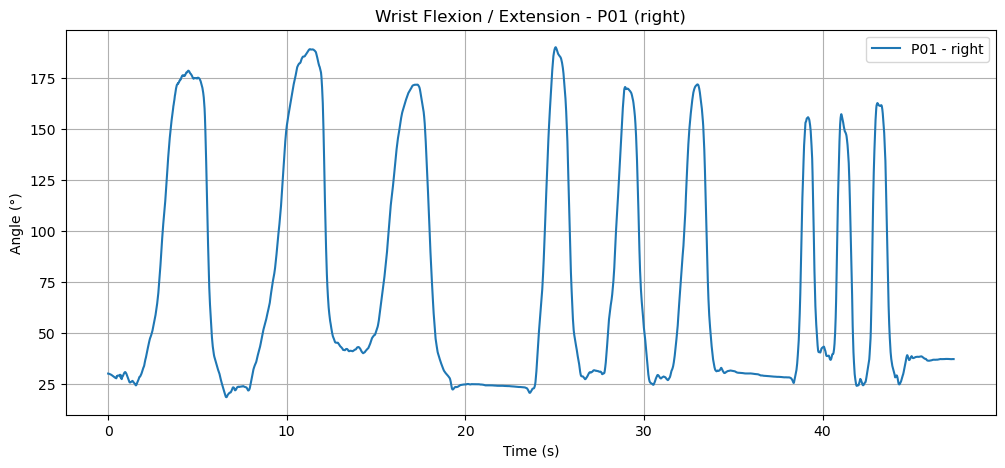

Min: 18.3920892447441
Max: 190.2271984960608

===== P02 | RIGHT =====


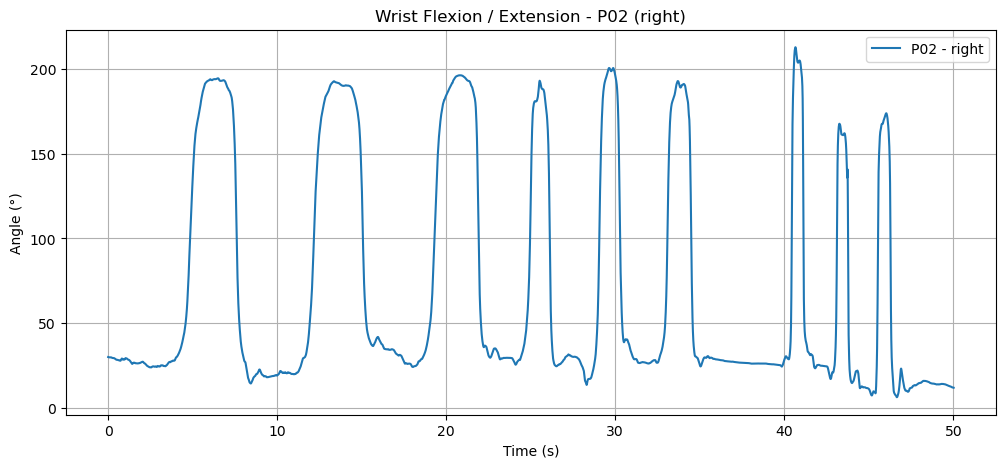

Min: 6.260529293243394
Max: 212.94951187346095

===== P03 | RIGHT =====


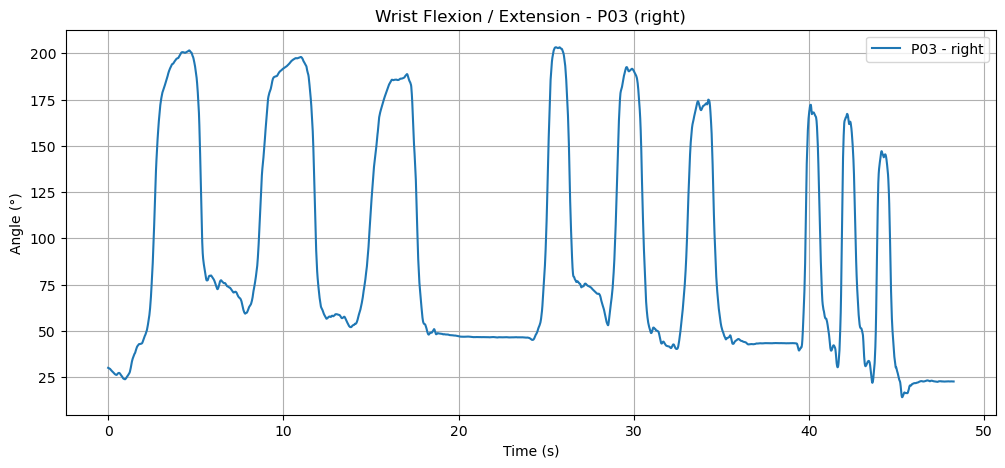

Min: 14.10811420226955
Max: 203.3182543280114


In [ ]:
# ==========================================================
# CONFIGURATION - PATIENT FILES
# ==========================================================
"""
Patient data configuration for passive elbow extension study.

Author: Anais Ragon + copilot 
Date: 21/04/2026
"""
import pandas as pd
import numpy as np
from io import StringIO
import os
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter
from scipy.ndimage import uniform_filter1d
import warnings
warnings.filterwarnings('ignore')

# ---------- PATIENT CONFIGURATION ----------
# Add your patients here following this structure
PATIENTS = {
    "P01": {
        "id": "Ch",
        "right": "Data_Ch_D.csv",
    

    },
    "P02": {
        "id": "Lo_1",
        "right": "Data_Lo_D_1.csv",
  
    },
    "P03": {
        "id": "Lo_2",
        "right": "Data_Lo_D_2.csv", 
    },
}

# Acquisition frequencies
FREQ_KPUSH = 1000  # Hz
FREQ_KMOVE = 250  # Hz

# ==========================================================
# LOAD FILE
# ==========================================================
def load_data(filename):

    candidate_dirs = [
        os.path.join("..", "data"),
        os.path.join(".", "data"),
        "."
    ]

    for base_dir in candidate_dirs:
        path = os.path.join(base_dir, filename)

        if os.path.exists(path):
            with open(path, "r", encoding="utf-8") as f:
                return f.readlines()

        if os.path.isdir(base_dir):
            matches = [f for f in os.listdir(base_dir) if f.lower() == filename.lower()]
            if matches:
                with open(os.path.join(base_dir, matches[0]), "r", encoding="utf-8") as f:
                    return f.readlines()

    raise FileNotFoundError(f"File not found: {filename}")


# ==========================================================
# PROCESS FILE
# ==========================================================
def process_file(filename):

    lines = load_data(filename)

    # ---------- FIND BLOCKS ----------
    idx_push, idx_move = None, None

    for i, line in enumerate(lines):
        if "K-Push" in line:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    if idx_push < idx_move:
        push_lines = lines[idx_push:idx_move]
        move_lines = lines[idx_move:]
    else:
        push_lines = lines[idx_push:]
        move_lines = lines[idx_move:idx_push]

    # ---------- K-PUSH ----------
    header_idx_push = next(i for i, l in enumerate(push_lines) if "temps" in l)

    df_push = pd.read_csv(
        StringIO("".join(push_lines[header_idx_push:])),
        sep=r"\t|,",
        engine="python"
    ).dropna(axis=1, how='all')

    df_push = df_push.rename(columns={"temps (seconde)": "time", "CHANNEL_1": "force"})
    df_push = df_push[["time", "force"]].apply(pd.to_numeric, errors='coerce').dropna()

    # ---------- BASELINE ----------
    baseline = {"wrist": [], "shoulder": []}

    for line in move_lines:
        if "Quaternion de base" in line:

            parts = line.strip().split("\t")
            if len(parts) < 5:
                parts = line.strip().split(",")

            values = []
            for x in parts[1:]:
                try:
                    values.append(float(x))
                except:
                    continue

            values = values[:4]

            if "S121577" in parts[0]:
                baseline["wrist"] = values
            elif "S121578" in parts[0]:
                baseline["shoulder"] = values

    # ---------- MOVE DATA ----------
    header_idx_move = next(i for i, l in enumerate(move_lines) if "temps" in l)

    rows = []
    for line in move_lines[header_idx_move + 1:]:
        r = line.strip().split("\t")
        if len(r) < 2:
            r = line.strip().split(",")
        rows.append(r)

    df_move = pd.DataFrame(rows).dropna(axis=1, how='all')
    df_move = df_move.apply(pd.to_numeric, errors='coerce').ffill().bfill()

    # ---------- SENSORS ----------
    df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
    df_wrist.columns = ["time","qx","qy","qz","qw"]

    df_shoulder = df_move.iloc[:, [0,6,7,8,9]].copy()
    df_shoulder.columns = ["time","qx","qy","qz","qw"]

    # ---------- DEBUG PRINT ----------
    print(f"\n===== FILE: {filename} =====")
    print("K-Push:\n", df_push.head())
    print("\nWrist:\n", df_wrist.head())
    print("\nShoulder:\n", df_shoulder.head())
    print("\nBaseline wrist:", baseline["wrist"])
    print("Baseline shoulder:", baseline["shoulder"])
    print("\nShapes:", df_push.shape, df_wrist.shape, df_shoulder.shape)

    return df_push, df_wrist, df_shoulder, baseline


# ==========================================================
# QUATERNION UTILS
# ==========================================================
def quat_conjugate(q):
    qx, qy, qz, qw = q
    return np.array([-qx, -qy, -qz, qw])

def quat_multiply(q1, q2):
    x1, y1, z1, w1 = q1
    x2, y2, z2, w2 = q2

    return np.array([
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2,
        w1*w2 - x1*x2 - y1*y2 - z1*z2
    ])

def normalize_quat(q):
    return q / np.linalg.norm(q)


# ==========================================================
# ANGLE CALCULATION
# ==========================================================
def quaternion_to_angle_y_calibrated(df_quat, baseline_quat, baseline_deg):

    q_base = normalize_quat(np.array(baseline_quat))
    q_base_inv = quat_conjugate(q_base)

    angles = []

    for i in range(len(df_quat)):

        q = np.array([
            df_quat["qx"].iloc[i],
            df_quat["qy"].iloc[i],
            df_quat["qz"].iloc[i],
            df_quat["qw"].iloc[i]
        ])

        q = normalize_quat(q)

        q_corr = quat_multiply(q_base_inv, q)
        qx, qy, qz, qw = q_corr

        angle = np.arctan2(
            2*(qw*qy + qx*qz),
            1 - 2*(qy**2 + qz**2)
        )

        angles.append(angle)

    angles = np.unwrap(np.array(angles))
    angle_deg = np.degrees(angles)

    angle_zeroed = angle_deg - angle_deg[0]

    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed

    angle_anatomical = angle_zeroed + baseline_deg

    df = df_quat[["time"]].copy()
    df["angle"] = angle_anatomical

    return df

# ==========================================================
# BUILD RESULTS (MULTI-PATIENTS)
# ==========================================================
results = {}

for patient_name, patient_data in PATIENTS.items():

    print(f"\n==============================")
    print(f"PATIENT: {patient_name} ({patient_data['id']})")
    print(f"==============================")

    results[patient_name] = {}

    for side in ["right"]:

        file = patient_data[side]

        try:
            df_push, df_wrist, df_shoulder, baseline = process_file(file)

            results[patient_name][side] = {
                "file": file,
                "push": df_push,
                "wrist": df_wrist,
                "shoulder": df_shoulder,
                "baseline": baseline
            }

            print(f"Loaded: {file}")

        except FileNotFoundError as e:
            print(f"[WARNING] {e}")

        all_angles_data = {}

# ==========================================================
# PROCESS + PLOT (MULTI-PATIENTS)
# ==========================================================
for patient_name in results:

    all_angles_data = {}

for patient_name in results:

    all_angles_data[patient_name] = {}

    for side in results[patient_name]:

        data = results[patient_name][side]

        print(f"\n===== {patient_name} | {side.upper()} =====")

        df_wrist = data["wrist"]
        baseline_quat = data["baseline"]["wrist"]

        if len(baseline_quat) != 4:
            print("⚠️ Baseline quaternion manquant → skip")
            continue

        df_angles = quaternion_to_angle_y_calibrated(
            df_wrist,
            baseline_quat,
            baseline_deg=30
        )

        # ✅ STOCKAGE ICI (C'EST ÇA QUI MANQUAIT)
        all_angles_data[patient_name][side] = df_angles

        # ---------- PLOT ----------
        plt.figure(figsize=(12,5))
        plt.plot(df_angles["time"], df_angles["angle"],
                 label=f"{patient_name} - {side}")

        plt.xlabel("Time (s)")
        plt.ylabel("Angle (°)")
        plt.title(f"Wrist Flexion / Extension - {patient_name} ({side})")
        plt.grid(True)
        plt.legend()
        plt.show()

        # ---------- CHECK ----------
        print("Min:", df_angles["angle"].min())
        print("Max:", df_angles["angle"].max())




===== EVENT DETECTION: P01 | RIGHT =====
Detected flexions: 10 | extensions: 9
First min : t=1.56s | angle=14.3°
Last  min : t=44.29s | angle=14.7°


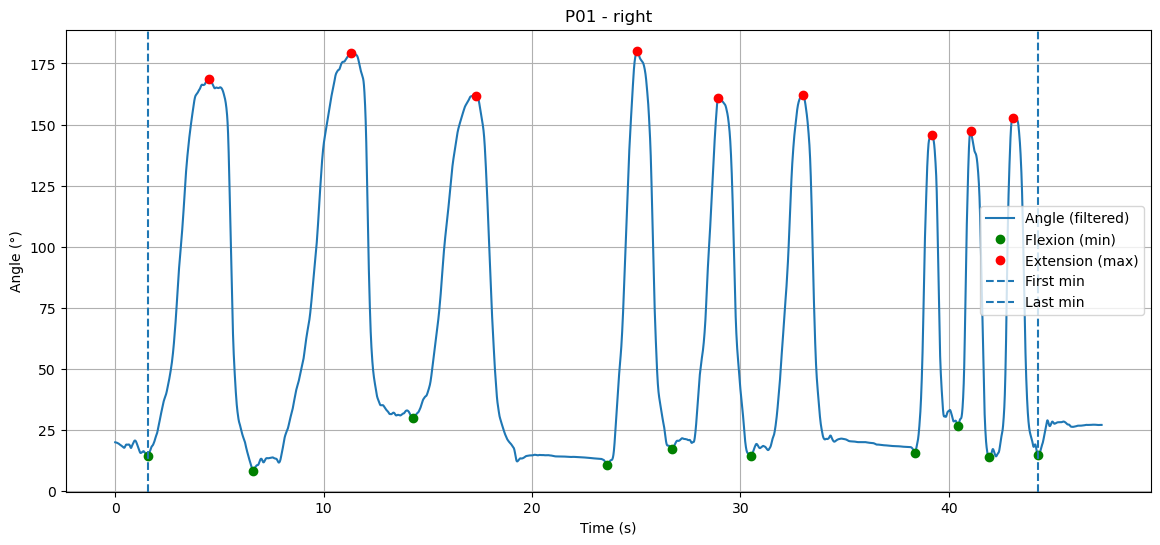


===== EVENT DETECTION: P02 | RIGHT =====
Detected flexions: 10 | extensions: 9
First min : t=2.54s | angle=13.9°
Last  min : t=47.32s | angle=-0.6°


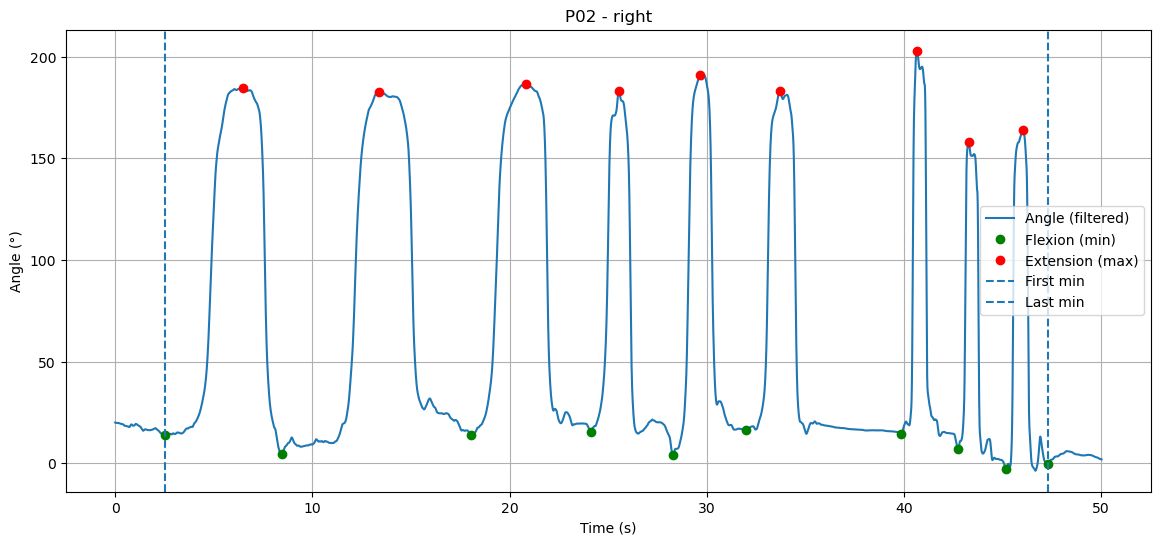


===== EVENT DETECTION: P03 | RIGHT =====
Detected flexions: 10 | extensions: 9
First min : t=0.96s | angle=13.8°
Last  min : t=45.32s | angle=4.1°


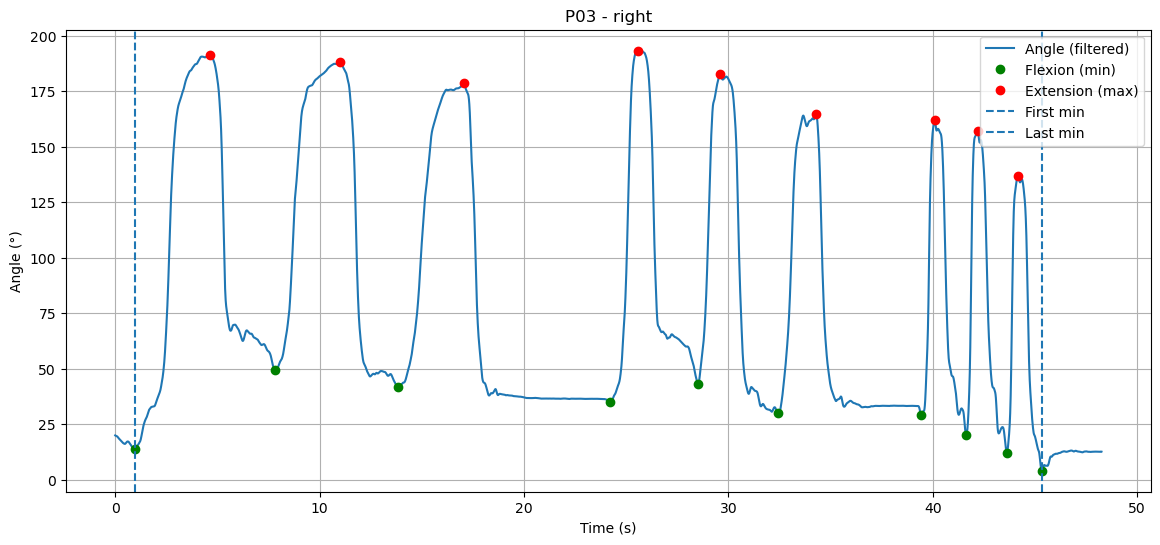

In [22]:
from scipy.signal import find_peaks, butter, filtfilt
import numpy as np
import matplotlib.pyplot as plt

# ---------- CONFIGURATION ----------
N_FLEXIONS = 10
N_EXTENSIONS = 9
MIN_AMPLITUDE = 20  # seuil amplitude

# ==========================================================
# BUTTERWORTH FILTER
# ==========================================================
def butter_lowpass_filter(signal, cutoff=10, fs=100, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist

    # sécurité pour éviter crash si fs trop faible
    if normal_cutoff >= 1:
        return signal

    b, a = butter(order, normal_cutoff, btype='low')
    return filtfilt(b, a, signal)


# ==========================================================
# MULTI-PATIENT EVENT DETECTION AND PLOTTING
# ==========================================================
events_results = {}

for patient_name in results:

    events_results[patient_name] = {}

    for side in results[patient_name]:

        print(f"\n===== EVENT DETECTION: {patient_name} | {side.upper()} =====")

        data = results[patient_name][side]

        df_wrist = data["wrist"]
        baseline_quat = data["baseline"]["wrist"]

        if len(baseline_quat) != 4:
            print("⚠️ Missing baseline → skip")
            continue

        # ---------- ANGLE ----------
        df_angles = quaternion_to_angle_y_calibrated(
            df_wrist,
            baseline_quat,
            baseline_deg=20
        )

        signal = df_angles["angle"].values
        time = df_angles["time"].values

        # ---------- AUTO SAMPLING FREQUENCY ----------
        fs = 1 / np.mean(np.diff(time))

        # ---------- BUTTERWORTH FILTER ----------
        signal = butter_lowpass_filter(signal, cutoff=10, fs=fs, order=4)

        # ---------- 1. INITIAL PEAK DETECTION ----------
        peaks_max_all, _ = find_peaks(signal, distance=50, prominence=5)
        peaks_min_all, _ = find_peaks(-signal, distance=50, prominence=5)

        # ---------- 2. ROBUST ALTERNATION ----------
        all_mins = np.sort(peaks_min_all)
        all_maxs = np.sort(peaks_max_all)

        peaks_flexion = []
        peaks_extension = []

        i, j = 0, 0

        # First min before first max
        while i < len(all_mins) and all_mins[i] < all_maxs[0]:
            peaks_flexion.append(all_mins[i])
            i += 1

        if len(peaks_flexion) == 0:
            first_max = all_maxs[0]
            closest_min = all_mins[np.argmin(np.abs(all_mins - first_max))]
            peaks_flexion.append(closest_min)

        # Alternating sequence
        while i < len(all_mins) and j < len(all_maxs):

            while j < len(all_maxs) and all_maxs[j] < peaks_flexion[-1]:
                j += 1
            if j >= len(all_maxs):
                break

            peaks_extension.append(all_maxs[j])
            j += 1

            while i < len(all_mins) and all_mins[i] < peaks_extension[-1]:
                i += 1
            if i >= len(all_mins):
                break

            peaks_flexion.append(all_mins[i])
            i += 1

        peaks_flexion = np.array(peaks_flexion)
        peaks_extension = np.array(peaks_extension)

        # ---------- 3. AMPLITUDE FILTER ----------
        filtered_flexion = []
        filtered_extension = []

        n_pairs = min(len(peaks_extension), len(peaks_flexion) - 1)

        for k in range(n_pairs):

            min_idx = peaks_flexion[k]
            max_idx = peaks_extension[k]

            amplitude = signal[max_idx] - signal[min_idx]

            if amplitude >= MIN_AMPLITUDE:
                filtered_flexion.append(min_idx)
                filtered_extension.append(max_idx)

        # ---------- ADD LAST MINIMUM ----------
        if len(peaks_flexion) > 0:
            last_min_candidate = peaks_flexion[-1]

            if len(filtered_flexion) == 0 or last_min_candidate != filtered_flexion[-1]:

                if len(filtered_extension) > 0:
                    last_max = filtered_extension[-1]
                    amplitude_last = abs(signal[last_min_candidate] - signal[last_max])
                else:
                    amplitude_last = MIN_AMPLITUDE

                if amplitude_last >= MIN_AMPLITUDE * 0.5:
                    filtered_flexion.append(last_min_candidate)

        peaks_flexion = np.array(filtered_flexion)
        peaks_extension = np.array(filtered_extension)

        # ---------- SAFETY ----------
        if len(peaks_flexion) == 0 or len(peaks_extension) == 0:
            print("⚠️ No valid events after filtering → skip")
            continue

        # ---------- LIMIT ----------
        peaks_flexion = peaks_flexion[:N_FLEXIONS]
        peaks_extension = peaks_extension[:N_EXTENSIONS]

        print(f"Detected flexions: {len(peaks_flexion)} | extensions: {len(peaks_extension)}")

        # ---------- FIRST / LAST ----------
        first_min = peaks_flexion[0]
        last_min = peaks_flexion[-1]

        print(f"First min : t={time[first_min]:.2f}s | angle={signal[first_min]:.1f}°")
        print(f"Last  min : t={time[last_min]:.2f}s | angle={signal[last_min]:.1f}°")

        # ---------- STORE ----------
        events_results[patient_name][side] = {
            "angles": df_angles,
            "peaks_flexion": peaks_flexion,
            "peaks_extension": peaks_extension,
            "first_min": first_min,
            "last_min": last_min
        }

        # ---------- PLOT ----------
        plt.figure(figsize=(14,6))

        plt.plot(time, signal, label="Angle (filtered)", linewidth=1.5)

        plt.plot(time[peaks_flexion], signal[peaks_flexion],
                 "go", label="Flexion (min)")

        plt.plot(time[peaks_extension], signal[peaks_extension],
                 "ro", label="Extension (max)")

        plt.axvline(time[first_min], linestyle='--', label='First min')
        plt.axvline(time[last_min], linestyle='--', label='Last min')

        plt.title(f"{patient_name} - {side}")
        plt.xlabel("Time (s)")
        plt.ylabel("Angle (°)")
        plt.legend()
        plt.grid(True)
        plt.show()


===== EVENTS: P01 | RIGHT =====

TABLE - P01 | right
 event_id speed_category  t_start  t_end  duration  amplitude   velocity
        1          lente   1.5560  4.492    2.9360 154.475865  52.614395
        2          lente   6.6159 11.296    4.6801 170.893314  36.514885
        3          lente  14.2760 17.312    3.0360 131.851319  43.429288
        4        moyenne  23.6039 25.052    1.4481 169.695196 117.184722
        5        moyenne  26.7080 28.936    2.2280 143.397307  64.361448
        6        moyenne  30.5160 33.000    2.4840 147.501872  59.380786
        7         rapide  38.3760 39.184    0.8080 130.482064 161.487703
        8         rapide  40.4440 41.048    0.6040 120.594737 199.660161
        9         rapide  41.9120 43.068    1.1560 138.832630 120.097431


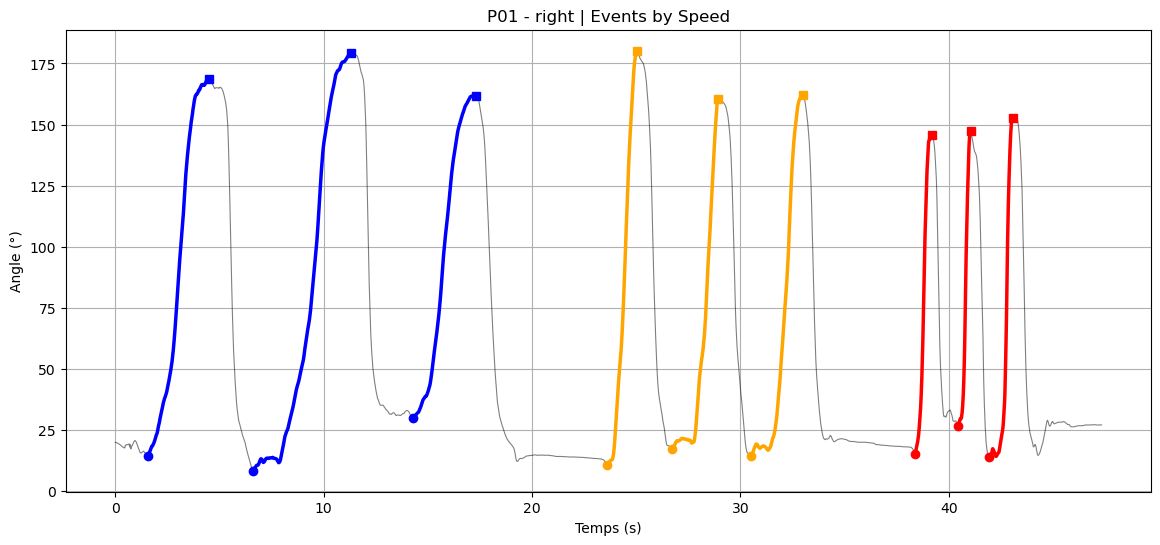


STATISTIQUES :

LENTE (n=3):
  Durée moyenne     : 3.55 s
  Amplitude moyenne : 152.4°
  Vitesse moyenne   : 44.2 °/s

MOYENNE (n=3):
  Durée moyenne     : 2.05 s
  Amplitude moyenne : 153.5°
  Vitesse moyenne   : 80.3 °/s

RAPIDE (n=3):
  Durée moyenne     : 0.86 s
  Amplitude moyenne : 130.0°
  Vitesse moyenne   : 160.4 °/s

===== EVENTS: P02 | RIGHT =====

TABLE - P02 | right
 event_id speed_category  t_start   t_end  duration  amplitude   velocity
        1          lente    2.536  6.4920    3.9560 170.722651  43.155372
        2          lente    8.432 13.3600    4.9280 178.422181  36.205800
        3          lente   18.020 20.8480    2.8280 172.268903  60.915454
        4        moyenne   24.108 25.5320    1.4240 167.598017 117.695237
        5        moyenne   28.304 29.6400    1.3360 187.132498 140.069235
        6        moyenne   31.972 33.7039    1.7319 166.778329  96.297898
        7         rapide   39.852 40.6560    0.8040 188.585051 234.558522
        8         rapide 

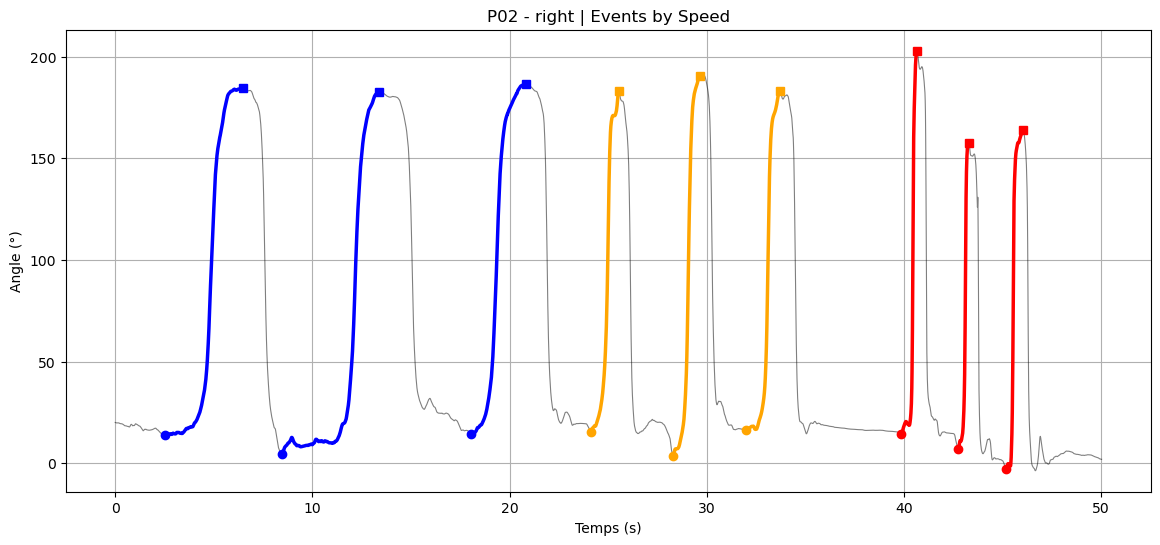


STATISTIQUES :

LENTE (n=3):
  Durée moyenne     : 3.90 s
  Amplitude moyenne : 173.8°
  Vitesse moyenne   : 46.8 °/s

MOYENNE (n=3):
  Durée moyenne     : 1.50 s
  Amplitude moyenne : 173.8°
  Vitesse moyenne   : 118.0 °/s

RAPIDE (n=3):
  Durée moyenne     : 0.73 s
  Amplitude moyenne : 168.6°
  Vitesse moyenne   : 237.4 °/s

===== EVENTS: P03 | RIGHT =====

TABLE - P03 | right
 event_id speed_category  t_start  t_end  duration  amplitude   velocity
        1          lente    0.956  4.628     3.672 177.791901  48.418274
        2          lente    7.820 10.988     3.168 138.794321  43.811339
        3          lente   13.848 17.052     3.204 136.845352  42.710784
        4        moyenne   24.212 25.552     1.340 158.236355 118.086832
        5        moyenne   28.524 29.588     1.064 139.516001 131.124061
        6        moyenne   32.448 34.276     1.828 134.651290  73.660443
        7         rapide   39.436 40.088     0.652 132.630963 203.421723
        8         rapide   41.63

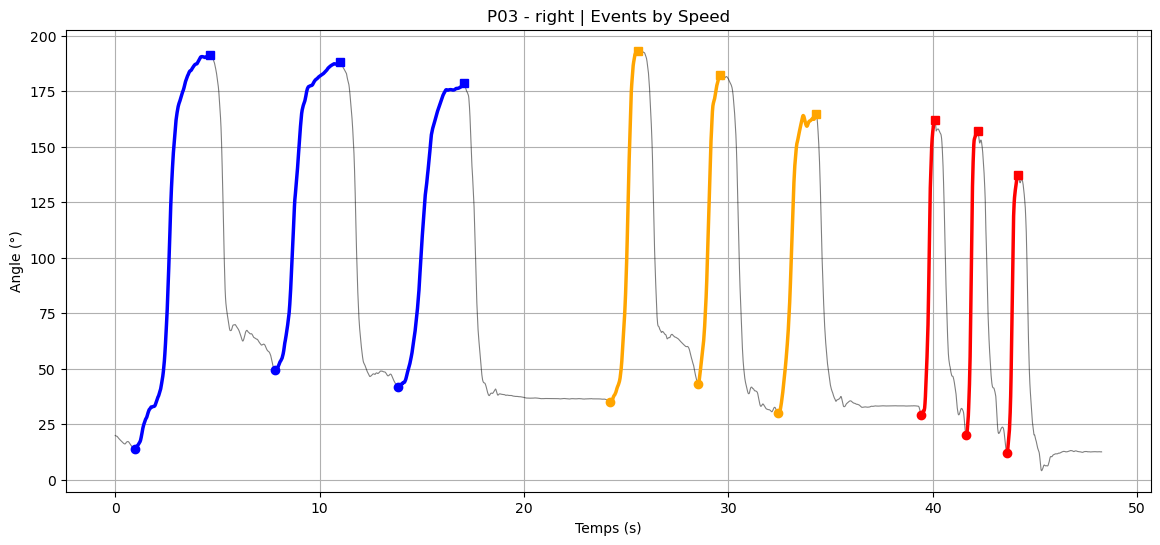


STATISTIQUES :

LENTE (n=3):
  Durée moyenne     : 3.35 s
  Amplitude moyenne : 151.1°
  Vitesse moyenne   : 45.0 °/s

MOYENNE (n=3):
  Durée moyenne     : 1.41 s
  Amplitude moyenne : 144.1°
  Vitesse moyenne   : 107.6 °/s

RAPIDE (n=3):
  Durée moyenne     : 0.58 s
  Amplitude moyenne : 131.6°
  Vitesse moyenne   : 229.5 °/s


In [23]:
# ==========================================================
# EVENTS ANALYSIS (MULTI-PATIENTS)
# ==========================================================
all_events_summary = {}

for patient_name in events_results:

    all_events_summary[patient_name] = {}

    for side in events_results[patient_name]:

        print(f"\n===== EVENTS: {patient_name} | {side.upper()} =====")

        data = events_results[patient_name][side]

        df_angles = data["angles"]
        peaks_flexion = data["peaks_flexion"]
        peaks_extension = data["peaks_extension"]

        signal = df_angles["angle"].values
        time = df_angles["time"].values

        # ---------- 5. EVENTS ----------
        events = []

        n_events = min(len(peaks_extension), len(peaks_flexion) - 1)

        for i in range(n_events):

            min_idx = peaks_flexion[i]
            max_idx = peaks_extension[i]

            t_start = time[min_idx]
            t_end = time[max_idx]
            duration = t_end - t_start

            angle_start = signal[min_idx]
            angle_end = signal[max_idx]
            amplitude = angle_end - angle_start

            velocity = amplitude / duration if duration > 0 else 0

            events.append({
                'event_id': i + 1,
                'min_idx': min_idx,
                'max_idx': max_idx,
                't_start': t_start,
                't_end': t_end,
                'duration': duration,
                'angle_start': angle_start,
                'angle_end': angle_end,
                'amplitude': amplitude,
                'velocity': velocity
            })

        # ---------- 6. CLASSIFICATION ----------
        speed_labels = ['lente'] * 3 + ['moyenne'] * 3 + ['rapide'] * 3

        for i, event in enumerate(events):
            if i < len(speed_labels):
                event['speed_category'] = speed_labels[i]
            else:
                event['speed_category'] = 'extra'

        df_events = pd.DataFrame(events)

        all_events_summary[patient_name][side] = df_events

        # ---------- 7. TABLE ----------
        print("\n" + "="*60)
        print(f"TABLE - {patient_name} | {side}")
        print("="*60)

        print(df_events[['event_id', 'speed_category',
                         't_start', 't_end',
                         'duration', 'amplitude', 'velocity']].to_string(index=False))

        # ---------- 8. PLOT ----------
        colors_speed = {'lente': 'blue', 'moyenne': 'orange', 'rapide': 'red', 'extra': 'gray'}

        plt.figure(figsize=(14,6))
        plt.plot(time, signal, 'k-', linewidth=0.8, alpha=0.5)

        for event in events:
            color = colors_speed[event['speed_category']]

            idx_range = np.arange(event['min_idx'], event['max_idx'] + 1)

            plt.plot(time[idx_range], signal[idx_range],
                     color=color, linewidth=2.5)

            plt.plot(time[event['min_idx']], signal[event['min_idx']],
                     'o', color=color)

            plt.plot(time[event['max_idx']], signal[event['max_idx']],
                     's', color=color)

        plt.title(f"{patient_name} - {side} | Events by Speed")
        plt.xlabel("Temps (s)")
        plt.ylabel("Angle (°)")
        plt.grid(True)
        plt.show()

        # ---------- 9. STATS ----------
        print("\nSTATISTIQUES :")

        for cat in ['lente', 'moyenne', 'rapide']:
            subset = df_events[df_events['speed_category'] == cat]

            if len(subset) == 0:
                continue

            print(f"\n{cat.upper()} (n={len(subset)}):")
            print(f"  Durée moyenne     : {subset['duration'].mean():.2f} s")
            print(f"  Amplitude moyenne : {subset['amplitude'].mean():.1f}°")
            print(f"  Vitesse moyenne   : {subset['velocity'].mean():.1f} °/s")

In [24]:
# ==========================================================
# BUILD CLEAN SUMMARY + ICC TABLE
# ==========================================================

def build_summary_and_icc(all_events_summary, all_angles_data):

    rows = []

    for patient_id in all_events_summary:

        for side in all_events_summary[patient_id]:

            df_events = all_events_summary[patient_id][side]
            df_angles = all_angles_data[patient_id][side]

            side_label = "D" if side == "right" else "G"

            for _, event in df_events.iterrows():

                # --------- EXTRACTION SIGNAL ----------
                mask = (df_angles["time"] >= event["t_start"]) & \
                       (df_angles["time"] <= event["t_end"])

                df_segment = df_angles.loc[mask]

                if len(df_segment) < 2:
                    continue

                # --------- VITESSE ----------
                velocity = np.gradient(
                    df_segment["angle"].values,
                    df_segment["time"].values
                )

                vel_mean = np.mean(velocity)
                vel_max = np.max(np.abs(velocity))

                rows.append({
                    "patient_id": patient_id,
                    "side": side_label,
                    "speed": event["speed_category"],
                    "trial": int(event["event_id"]),
                    "vel_mean": vel_mean,
                    "vel_max": vel_max
                })

    df = pd.DataFrame(rows)

    # ======================================================
    # FORMAT ICC (WIDE)
    # ======================================================

    df["trial_in_speed"] = df.groupby(
        ["patient_id", "side", "speed"]
    ).cumcount() + 1

    df_icc_mean = df.pivot_table(
        index=["patient_id", "side", "speed"],
        columns="trial_in_speed",
        values="vel_mean"
    )

    df_icc_max = df.pivot_table(
        index=["patient_id", "side", "speed"],
        columns="trial_in_speed",
        values="vel_max"
    )

    df_icc_mean.columns = [f"trial_{int(c)}" for c in df_icc_mean.columns]
    df_icc_max.columns = [f"trial_{int(c)}" for c in df_icc_max.columns]

    df_icc_mean = df_icc_mean.reset_index()
    df_icc_max = df_icc_max.reset_index()

    return df, df_icc_mean, df_icc_max


# ==========================================================
# 🧠 AFFICHAGE LISIBLE AMÉLIORÉ
# ==========================================================

def pretty_print_icc(df_icc, title):

    print("\n" + "="*100)
    print(title)
    print("="*100)

    for patient in df_icc["patient_id"].unique():

        print("\n" + "#"*100)
        print(f"PATIENT: {patient}")
        print("#"*100)

        df_p = df_icc[df_icc["patient_id"] == patient]

        for side in df_p["side"].unique():

            print(f"\n----- SIDE: {side} -----")

            df_s = df_p[df_p["side"] == side]

            for speed in ["lente", "moyenne", "rapide"]:

                df_sp = df_s[df_s["speed"] == speed]

                if len(df_sp) == 0:
                    continue

                print(f"\n>>> SPEED: {speed.upper()}")

                print(df_sp.to_string(index=False))

                print("-"*60)

        print("\n" + "="*100)


# ==========================================================
# RUN
# ==========================================================

df_long, df_icc_mean, df_icc_max = build_summary_and_icc(
    all_events_summary,
    all_angles_data
)

# ==========================================================
# DISPLAY LONG FORMAT
# ==========================================================

print("\n" + "="*120)
print("LONG FORMAT (RAW - STRUCTURED FOR R)")
print("="*120)

for patient in df_long["patient_id"].unique():

    print("\n" + "#"*120)
    print(f"PATIENT: {patient}")
    print("#"*120)

    df_p = df_long[df_long["patient_id"] == patient]

    for speed in ["lente", "moyenne", "rapide"]:

        df_s = df_p[df_p["speed"] == speed]

        if df_s.empty:
            continue

        print("\n" + "-"*40)
        print(f"SPEED: {speed.upper()}")
        print("-"*40)

        print(df_s[["side","trial","vel_mean","vel_max"]].to_string(index=False))

        print("")

    print("\n" + "="*120 + "\n")

# ==========================================================
# SPEED SUMMARY (V1 / V2 / V3 MEAN PER PATIENT)
# ==========================================================

def speed_summary(df_long):

    print("\n" + "="*120)
    print("MEAN VELOCITY SUMMARY (V1 / V2 / V3) PER PATIENT")
    print("="*120)

    for patient in df_long["patient_id"].unique():

        print("\n" + "#"*120)
        print(f"PATIENT: {patient}")
        print("#"*120)

        df_p = df_long[df_long["patient_id"] == patient]

        for side in df_p["side"].unique():

            print(f"\n----- SIDE: {side} -----")

            df_s = df_p[df_p["side"] == side]

            summary = (
                df_s.groupby("speed")[["vel_mean", "vel_max"]]
                .mean()
                .reindex(["lente", "moyenne", "rapide"])
            )

            # rename propre pour lecture
            summary.index = ["V1 (lente)", "V2 (moyenne)", "V3 (rapide)"]

            print(summary.round(2).to_string())
            print("\n" + "-"*60)

        print("\n" + "="*120)



LONG FORMAT (RAW - STRUCTURED FOR R)

########################################################################################################################
PATIENT: P01
########################################################################################################################

----------------------------------------
SPEED: LENTE
----------------------------------------
side  trial  vel_mean    vel_max
   D      1 52.545866 169.102038
   D      2 36.486568 168.851945
   D      3 43.375080 136.392309


----------------------------------------
SPEED: MOYENNE
----------------------------------------
side  trial   vel_mean    vel_max
   D      4 116.885638 281.737843
   D      5  64.262615 228.719529
   D      6  59.282858 279.945956


----------------------------------------
SPEED: RAPIDE
----------------------------------------
side  trial   vel_mean    vel_max
   D      7 160.692932 503.518868
   D      8 198.330474 644.866171
   D      9 119.704052 696.928792




#####


GENERATING REPRODUCIBILITY PLOTS


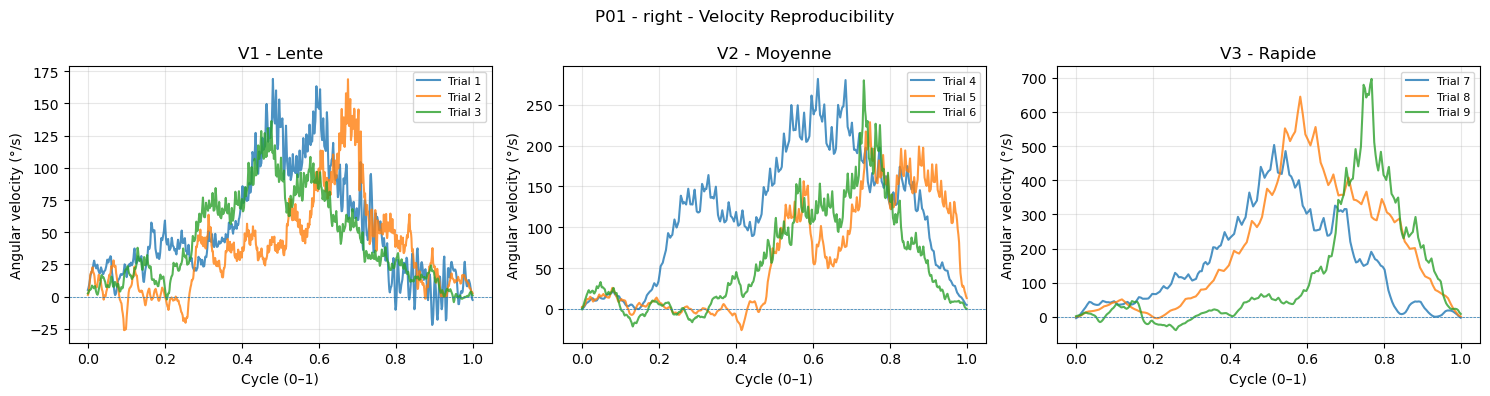

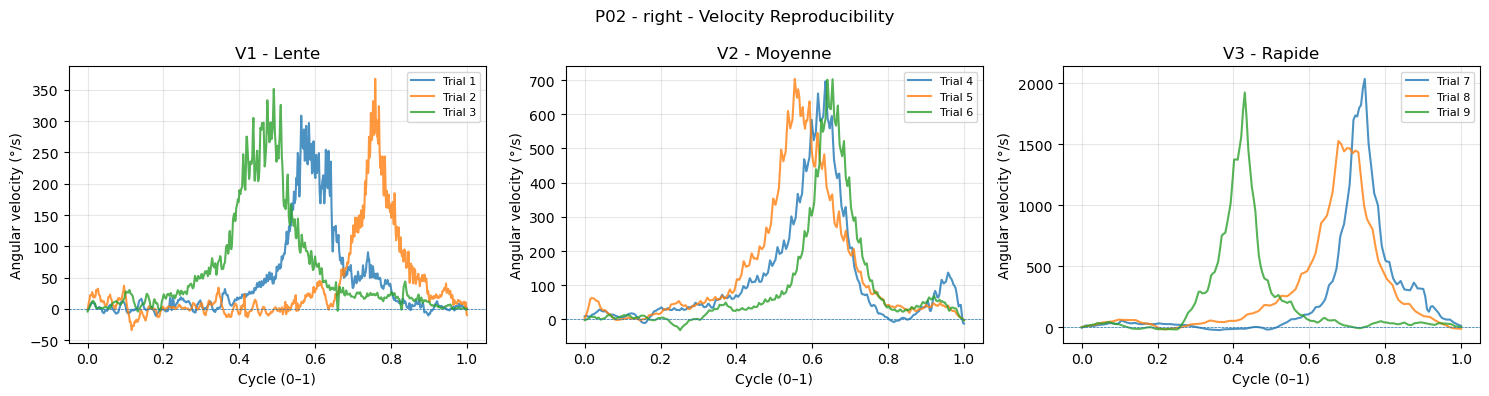

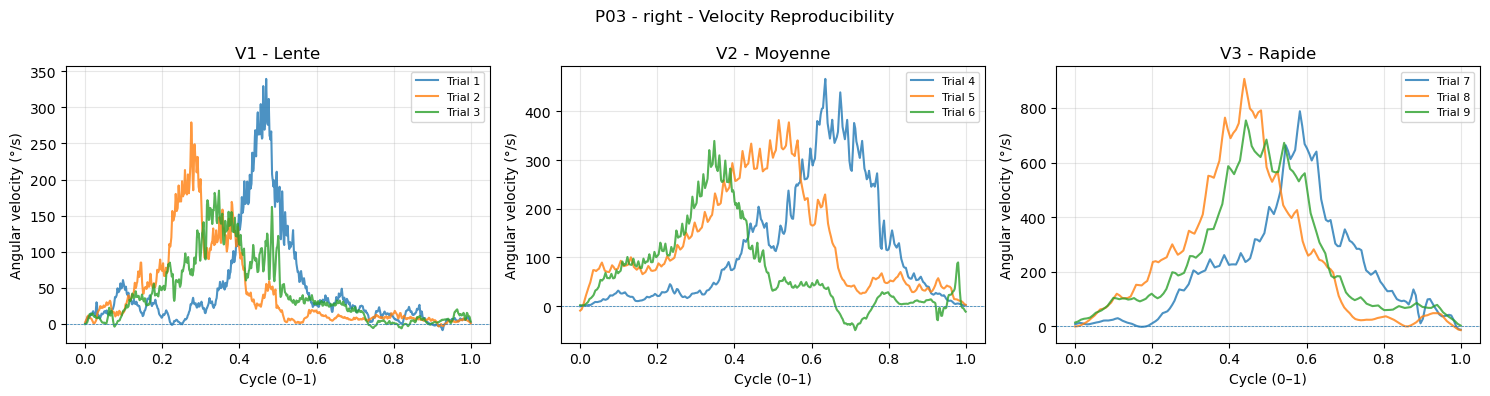

In [ ]:
# ==========================================================
# REPRODUCIBILITY VISUALIZATION 
# ==========================================================

def extract_event_signal(df_angles, t_start, t_end):

    mask = (df_angles["time"] >= t_start) & (df_angles["time"] <= t_end)
    df_segment = df_angles.loc[mask].copy()

    if len(df_segment) < 2:
        return None, None, None

    t = df_segment["time"].values

    # Avoid division by zero
    if t[-1] == t[0]:
        return None, None, None

    # Normalize time (0 → 1)
    t_norm = (t - t[0]) / (t[-1] - t[0])

    angle = df_segment["angle"].values
    velocity = np.gradient(angle, t)

    return t_norm, angle, velocity


# ==========================================================
# BUILD EVENTS FROM YOUR STRUCTURE
# ==========================================================

def build_events_for_patient(all_events_summary, all_angles_data, patient_id, side):

    events = []

    if side not in all_events_summary[patient_id]:
        return events

    df_events = all_events_summary[patient_id][side]
    df_angles = all_angles_data[patient_id][side]

    for _, event in df_events.iterrows():

        t_norm, angle, velocity = extract_event_signal(
            df_angles,
            event["t_start"],
            event["t_end"]
        )

        if t_norm is None:
            continue

        events.append({
            "trial": event["event_id"],
            "speed": event["speed_category"],  # lente / moyenne / rapide
            "time": t_norm,
            "angle": angle,
            "velocity": velocity
        })

    return events


# ==========================================================
# VELOCITY PLOT
# ==========================================================

def plot_velocity_reproducibility(events, patient_id, side):

    if len(events) == 0:
        print(f"No events for {patient_id} {side}")
        return

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    speeds = ["lente", "moyenne", "rapide"]
    titles = ["V1 - Lente", "V2 - Moyenne", "V3 - Rapide"]

    for i, (speed, title) in enumerate(zip(speeds, titles)):

        ax = axes[i]
        subset = [e for e in events if e["speed"] == speed]

        for event in subset:
            ax.plot(event["time"], event["velocity"],
                    label=f"Trial {event['trial']}",
                    linewidth=1.5,
                    alpha=0.8)

        ax.set_title(title)
        ax.set_xlabel("Cycle (0–1)")
        ax.set_ylabel("Angular velocity (°/s)")
        ax.grid(True, alpha=0.3)
        ax.axhline(y=0, linestyle='--', linewidth=0.5)

        if len(subset) > 0:
            ax.legend(fontsize=8)

    plt.suptitle(f"{patient_id} - {side} - Velocity Reproducibility")
    plt.tight_layout()
    plt.show()



# ==========================================================
# RUN FOR ALL PATIENTS
# ==========================================================

print("\n" + "="*60)
print("GENERATING REPRODUCIBILITY PLOTS")
print("="*60)

for patient_id in all_events_summary:

    for side in all_events_summary[patient_id]:

        events = build_events_for_patient(
            all_events_summary,
            all_angles_data,
            patient_id,
            side
        )

        plot_velocity_reproducibility(events, patient_id, side)
     #   plot_angle_reproducibility(events, patient_id, side)